In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import utils
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train_norm = x_train.reshape(60000, 784) / 255.0
x_test_norm = x_test.reshape(10000, 784) / 255.0

y_train_cat = utils.to_categorical(y_train, 10)
y_test_cat = utils.to_categorical(y_test, 10)
print("Дані готові до фінальної битви!")

Дані готові до фінальної битви!


In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(784,)))

    activation_choice = hp.Choice('activation', values=['relu', 'sigmoid', 'tanh', 'elu', 'selu'])

    for i in range(hp.Int('num_layers', 2, 5)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=128, max_value=1024, step=32),
            activation=activation_choice
        ))

    model.add(Dense(10, activation='softmax'))

    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'SGD'])

    model.compile(
        optimizer=optimizer_choice,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:

tuner_rs = kt.RandomSearch(
    build_model, objective='val_accuracy', max_trials=5,
    directory='tuner_results', project_name='lab3_part4_rs'
)

tuner_hb = kt.Hyperband(
    build_model, objective='val_accuracy', max_epochs=15, factor=3,
    directory='tuner_results', project_name='lab3_part4_hb'
)

tuner_bo = kt.BayesianOptimization(
    build_model, objective='val_accuracy', max_trials=5,
    directory='tuner_results', project_name='lab3_part4_bo'
)

print("Тюнери ініціалізовано!")

Тюнери ініціалізовано!


In [ ]:
stop_early = EarlyStopping(monitor='val_accuracy', patience=2)

fit_params = {
    'x': x_train_norm, 'y': y_train_cat,
    'batch_size': 64, 'epochs': 50,
    'validation_split': 0.2,
    'callbacks': [stop_early],
    'verbose': 1
}

print("--- СТАРТ RANDOM SEARCH ---")
tuner_rs.search(**fit_params)

print("\n--- СТАРТ HYPERBAND ---")
tuner_hb.search(**fit_params)

print("\n--- СТАРТ BAYESIAN OPTIMIZATION ---")
tuner_bo.search(**fit_params)

Trial 5 Complete [00h 00m 58s]
val_accuracy: 0.8879166841506958

Best val_accuracy So Far: 0.8879166841506958
Total elapsed time: 00h 03m 48s


/Users/bohdan_best/Documents/університет/4 курс/Deep Learning/lab1/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(store)



Точність Random Search: 88.54%
Точність Hyperband: 88.13%
Точність Bayesian Opt: 88.11%

Абсолютно найкращу модель збережено у файл 'best_tuner_model.keras'


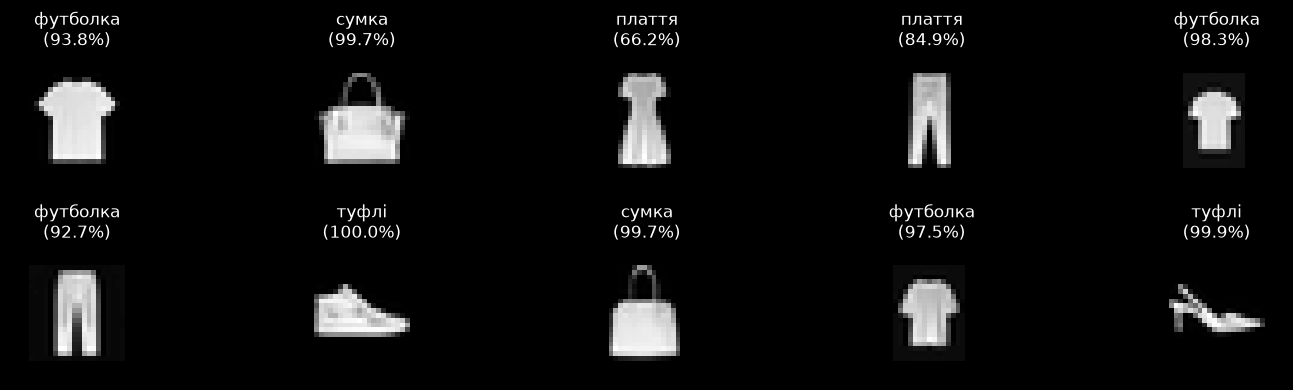

In [ ]:
best_rs = tuner_rs.get_best_models(num_models=1)[0]
best_hb = tuner_hb.get_best_models(num_models=1)[0]
best_bo = tuner_bo.get_best_models(num_models=1)[0]

_, acc_rs = best_rs.evaluate(x_test_norm, y_test_cat, verbose=0)
_, acc_hb = best_hb.evaluate(x_test_norm, y_test_cat, verbose=0)
_, acc_bo = best_bo.evaluate(x_test_norm, y_test_cat, verbose=0)

print(f"\nТочність Random Search: {acc_rs*100:.2f}%")
print(f"Точність Hyperband: {acc_hb*100:.2f}%")
print(f"Точність Bayesian Opt: {acc_bo*100:.2f}%")

models_dict = {acc_rs: best_rs, acc_hb: best_hb, acc_bo: best_bo}
ultimate_best_model = models_dict[max(models_dict.keys())]

ultimate_best_model.save('best_tuner_model.keras')
print("\nАбсолютно найкращу модель збережено у файл 'best_tuner_model.keras'")

classes = ['футболка', 'штани', 'светр', 'плаття', 'пальто',
           'туфлі', 'сорочка', 'кросівки', 'сумка', 'черевики']

def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    img_inverted = ImageOps.invert(img)
    bbox = img_inverted.getbbox()
    if bbox:
        img_inverted = img_inverted.crop(bbox)
    final_img = Image.new('L', (28, 28), color=0)
    img_inverted.thumbnail((20, 20), Image.Resampling.LANCZOS)
    offset_x = (28 - img_inverted.width) // 2
    offset_y = (28 - img_inverted.height) // 2
    final_img.paste(img_inverted, (offset_x, offset_y))
    img_array = np.array(final_img) / 255.0
    return img_array, img_array.reshape(1, 784)

images_folder = 'test_images'
image_files = [f for f in os.listdir(images_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

plt.figure(figsize=(15, 2 * ((len(image_files) + 4) // 5)))
for i, file_name in enumerate(image_files):
    img_path = os.path.join(images_folder, file_name)
    img_plot, img_for_model = preprocess_image(img_path)

    prediction = ultimate_best_model.predict(img_for_model, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    plt.subplot(((len(image_files) + 4) // 5), 5, i + 1)
    plt.imshow(img_plot, cmap='gray')
    plt.title(f"{classes[predicted_class]}\n({confidence:.1f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from IPython.display import display

results_data = {
    "Етап лабораторної": [
        "Частина 1 (Базова)", 
        "Частина 2 (Баєсівська)", 
        "Частина 3 (Мульти-параметри)", 
        "Частина 4 (Битва тюнерів)"
    ],
    "Алгоритм пошуку": [
        "RandomSearch", 
        "BayesianOptimization", 
        "BayesianOptimization", 
        "RandomSearch (Переможець)"
    ],
    "К-сть прихованих шарів": [
        "1 (фіксовано)", 
        "2 (фіксовано)", 
        "2 (фіксовано)", 
        "5 (динамічно)"
    ],
    "Нейрони по шарах": [
        "Шар 1: 288", 
        "Шар 1: 800 | Шар 2: 352", 
        "Шар 1: 672 | Шар 2: 128", 
        "Ш1:128 | Ш2:352 | Ш3:832 | Ш4:928 | Ш5:128"
    ],
    "Активація": [
        "relu", 
        "relu", 
        "sigmoid", 
        "relu"
    ],
    "Оптимізатор": [
        "SGD", 
        "SGD", 
        "rmsprop", 
        "adam"
    ],
    "Точність (Тест)": [
        "86.86%", 
        "87.94%", 
        "88.41%", 
        "88.54%"
    ]
}

df_results = pd.DataFrame(results_data)

styled_table = (
    df_results.style
    .set_caption("Зведена таблиця найкращих гіперпараметрів нейромережі")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]
    },
    {
        'selector': 'th',
        'props': [('text-align', 'center'), ('background-color', '#f4f4f4'), ('color', '#333')]
    },
    {
        'selector': 'td',
        'props': [('text-align', 'center')]
    }])
    .hide(axis="index")
)

display(styled_table)

Етап лабораторної,Алгоритм пошуку,К-сть прихованих шарів,Нейрони по шарах,Активація,Оптимізатор,Точність (Тест)
Частина 1 (Базова),RandomSearch,1 (фіксовано),Шар 1: 288,relu,SGD,86.86%
Частина 2 (Баєсівська),BayesianOptimization,2 (фіксовано),Шар 1: 800 | Шар 2: 352,relu,SGD,87.94%
Частина 3 (Мульти-параметри),BayesianOptimization,2 (фіксовано),Шар 1: 672 | Шар 2: 128,sigmoid,rmsprop,88.41%
Частина 4 (Битва тюнерів),RandomSearch (Переможець),5 (динамічно),Ш1:128 | Ш2:352 | Ш3:832 | Ш4:928 | Ш5:128,relu,adam,88.54%
